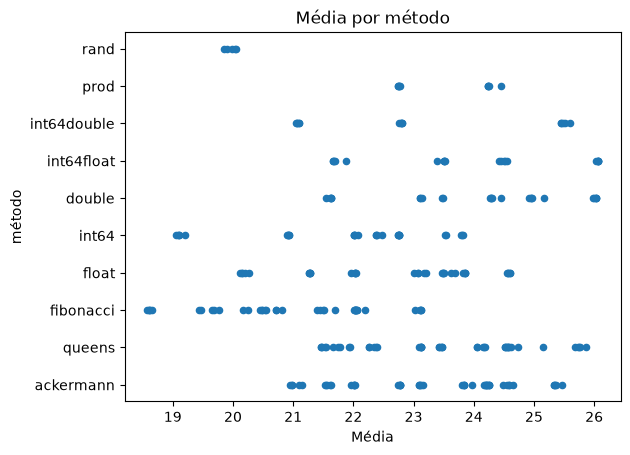

                                             Stress-ng      Média  Variância  \
1    stress-ng---cpu-3---cpu-method-ackermann--t-30...  24.182785   0.030873   
3    stress-ng---cpu-3---cpu-method-ackermann--t-30...  24.173482   0.023777   
5    stress-ng---cpu-3---cpu-method-ackermann--t-30...  24.210045   0.009455   
7    stress-ng---cpu-3---cpu-method-ackermann--t-30...  24.211547   0.009224   
9    stress-ng---cpu-3---cpu-method-ackermann--t-30...  21.527191   0.030125   
..                                                 ...        ...        ...   
539  stress-ng---cpu-3---cpu-method-rand--t-30-stre...  20.029361   0.016672   
541  stress-ng---cpu-3---cpu-method-rand--t-30-stre...  19.857761   0.014760   
543  stress-ng---cpu-3---cpu-method-rand--t-30-stre...  19.976036   0.015714   
545  stress-ng---cpu-3---cpu-method-rand--t-30-stre...  19.898930   0.018781   
547  stress-ng---cpu-3---cpu-method-rand--t-30-stre...  20.051998   0.013574   

        método     cpu tempo    data  


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#cons = pd.read_csv("log_medicao_sequencial.csv")
#cons = pd.read_csv("log_residual_com_frequency_demand.csv")
cons = pd.read_csv("log_medicao_paralela.csv")

'''cons = cons.rename(columns={
    "stress-ng---cpu-6---cpu-method-queens--t-30-20260924_121141.csv": "Stress-ng",
    "24.4723993227684": "Info",
    "0.008322237037118985": "Média"
    })
'''

#print(cons.columns)

#cons = cons[~cons.astype(str).apply(lambda linha : linha.str.contains("n"),any(), axis=1)]

filtrado = cons.copy()

colunas = filtrado.columns.tolist()

colunas[0] = "Stress-ng"
colunas[1] = "Média"
colunas[2] = "Variância"

filtrado.columns = colunas
filtrado = filtrado.dropna(subset=["Variância"])

filtrado['método'] = filtrado['Stress-ng'].str.extract(r'-method-([^-]+)')

filtrado['cpu'] = filtrado["Stress-ng"].str.split('--').str[1]

filtrado['tempo'] = filtrado['Stress-ng'].str.extract(r't-([^-]+)')
#tempo = filtrado["Stress-ng"].str.split('--').str[3]
#filtrado['tempo'] = tempo.str.split('-').str[1]

filtrado['data'] = filtrado['Stress-ng'].str.extract(r't-30-([^-]+)')
#data = filtrado["Stress-ng"].str.split('-').str[14]
#filtrado["data"] = data.str.split('_').str[0]

grupo = filtrado.groupby("método")["Média"]
#variância = grupo.var()


repres = filtrado.plot(x="Média", y="método", kind="scatter", title="Média por método")



plt.show()
print(filtrado)
#print(variância)







